In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
import argparse
import json

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN, HierarchicalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils
# from pypalettes import load_cmap

import pandas as pd
import seaborn as sns

Apr-10-2025-12-30-07: tanh tpc

Apr-10-2025-11-38-15: non-sparse pcn

Apr-10-2025-11-21-07: non-relu pcn

Apr-10-2025-11-19-06: regular pcn

In [9]:
pcn_path = 'Apr-10-2025-11-19-06'
pcn_non_negative_path = 'Apr-10-2025-11-21-07'
pcn_non_sparse_path = 'Apr-10-2025-11-38-15'
tpc_path = 'Mar-24-2025-10-48-57'
tpc_non_negative_path = 'Apr-10-2025-12-30-07'
rnn_path = 'Apr-28-2025-12-10-16'

In [10]:
pcn_scores = np.load(os.path.join('../results/pcn', pcn_path, 'grid_scores.npy'))
pcn_non_negative_scores = np.load(os.path.join('../results/pcn', pcn_non_negative_path, 'grid_scores.npy'))
pcn_non_sparse_scores = np.load(os.path.join('../results/pcn', pcn_non_sparse_path, 'grid_scores.npy'))
tpc_scores = np.load(os.path.join('../results/tpc', tpc_path, 'grid_scores.npy'))
tpc_non_negative_scores = np.load(os.path.join('../results/tpc', tpc_non_negative_path, 'grid_scores.npy'))
rnn_scores = np.load(os.path.join('../results/rnn', rnn_path, 'grid_scores.npy'))

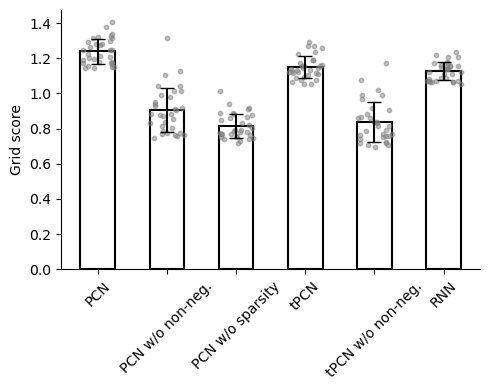

In [11]:
n_cells = 32
pcn_scores = pcn_scores[:n_cells]
pcn_non_sparse_scores = pcn_non_sparse_scores[:n_cells]
pcn_non_negative_scores = pcn_non_negative_scores[:n_cells]
tpc_scores = tpc_scores[:n_cells]
tpc_non_negative_scores = tpc_non_negative_scores[:n_cells]
rnn_scores = rnn_scores[:n_cells]
scores = [pcn_scores, pcn_non_negative_scores, pcn_non_sparse_scores, tpc_scores, tpc_non_negative_scores, rnn_scores]
x = np.arange(len(scores))
y = np.array([pcn_scores.mean(), pcn_non_negative_scores.mean(), pcn_non_sparse_scores.mean(), tpc_scores.mean(), tpc_non_negative_scores.mean(), rnn_scores.mean()])
y_err = np.array([pcn_scores.std(), pcn_non_negative_scores.std(), pcn_non_sparse_scores.std(), tpc_scores.std(), tpc_non_negative_scores.std(), rnn_scores.std()])
w = 0.5

fig, ax = plt.subplots(figsize=(5, 4))
ax.spines[['right', 'top']].set_visible(False)
ax.bar(x, y, width=w, yerr=y_err, capsize=5, color='none', edgecolor='black', linewidth=1.5)
ax.set_xticks(x, ['PCN', 'PCN w/o non-neg.', 'PCN w/o sparsity', 'tPCN', 'tPCN w/o non-neg.', 'RNN'], rotation=45)
ax.set_ylabel('Grid score')
for i, score in enumerate(scores):
    for s in score:
        ax.scatter(i + np.random.random() * w - w / 2, s, color='gray', alpha=0.5, s=10, marker='o')
plt.tight_layout()
plt.savefig('../results/emergence/grid_scores.pdf', bbox_inches='tight')


In [12]:
tpc_rm = np.load(os.path.join('../results/tpc', tpc_path, 'top64_grid_cells.npy'))
tpc_non_negative_rm = np.load(os.path.join('../results/tpc', tpc_non_negative_path, 'top64_grid_cells.npy'))
pcn_rm = np.load(os.path.join('../results/pcn', pcn_path, 'grid_maps.npy'))
pcn_non_negative_rm = np.load(os.path.join('../results/pcn', pcn_non_negative_path, 'grid_maps.npy'))
pcn_non_sparse_rm = np.load(os.path.join('../results/pcn', pcn_non_sparse_path, 'grid_maps.npy'))
rnn_rm = np.load(os.path.join('../results/rnn', rnn_path, 'top64_grid_cells.npy'))

In [16]:
def plot_rms(rm, n_cells, n_cols, scores, save_name):
    fig, axes = plt.subplots(n_cells // n_cols, n_cols, figsize=(n_cols, n_cells //n_cols))
    for i, ax in enumerate(axes.flatten()):
        r = (rm[i] - rm[i].min()) / (rm[i].max() - rm[i].min() + 1e-10)
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}')
    plt.tight_layout()
    plt.savefig(f'../results/emergence/{save_name}.pdf', bbox_inches='tight')
    plt.show()

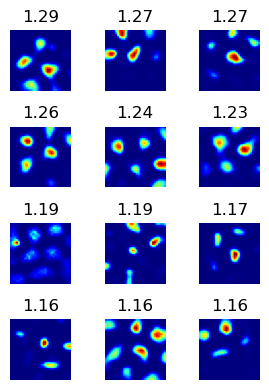

In [17]:
plot_rms(tpc_rm, n_cells=12, n_cols=3, scores=tpc_scores[:12], save_name='tpc_rm')

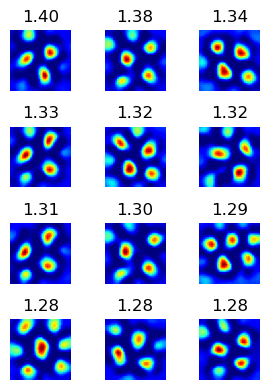

In [19]:
plot_rms(pcn_rm, n_cells=12, n_cols=3, scores=pcn_scores[:12], save_name='pcn_rm')

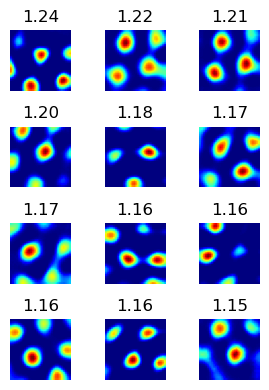

In [20]:
plot_rms(rnn_rm, n_cells=12, n_cols=3, scores=rnn_scores[:12], save_name='rnn_rm')

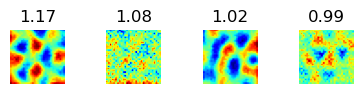

In [26]:
plot_rms(tpc_non_negative_rm, n_cells=4, scores=tpc_non_negative_scores[:16], save_name='tpc_non_negative_rm')

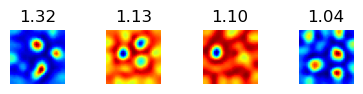

In [27]:
plot_rms(pcn_non_negative_rm, n_cells=4, scores=pcn_non_negative_scores[:16], save_name='pcn_non_negative_rm')

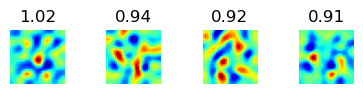

In [28]:
plot_rms(pcn_non_sparse_rm, n_cells=4, scores=pcn_non_sparse_scores[:16], save_name='pcn_non_sparse_rm')

In [29]:
class Options:
    def __init__(self):
        self.device = 'cuda'
        self.oned = False
        self.Np = 512
        self.Ng = 2048
        self.Nv = 2
        self.DoG = True
        self.box_width = 1.6
        self.box_height = 1.6
        self.place_cell_rf = 0.12
        self.surround_scale = 2
        self.periodic = False
        self.sequence_length = 10
        self.dt = 0.02
        self.batch_size = 500
        self.n_epochs = 120
        self.n_steps = 100
        self.learning_rate = 1e-4
        self.weight_decay = 1e-4
        self.decay_step_size = 50
        self.decay_rate = 0.9
        self.lambda_z = 0
        self.lambda_z_init = 0
        self.inf_iters = 20
        self.test_inf_iters = 20
        self.inf_lr = 2e-2
        self.out_activation = 'softmax'
        self.rec_activation = 'relu'
        self.restore = None
        self.preloaded_data = False
        self.save = True
        self.save_every = 50
        self.loss = 'CE'
        self.normalize_pc = 'softmax'
        self.is_wandb = False
        self.sweep = False
        self.mode = 'train'
        self.no_velocity = False
        self.truncating = 1
        self.rf_std = 0
        self.place_cell_rf_prob = None

    def load_from_json(self, json_file):
        with open(json_file, 'r') as file:
            data = json.load(file)
        
        # Set attributes from JSON, skip `_get_args` and `_get_kwargs`
        for key, value in data.items():
            if hasattr(self, key):
                setattr(self, key, value)

    def print_values(self):
        for key, value in self.__dict__.items():
            print(f'{key}: {value}')

In [30]:
def get_trajetories(tpc_path):
    options_tpc = Options()
    tpc_path = os.path.join('../results', 'tpc', tpc_path)
    options_tpc.load_from_json(os.path.join(tpc_path, 'configs.json'))
    ckpt_tpc = torch.load(os.path.join(tpc_path, 'models', 'most_recent_model.pth'), map_location=torch.device(options_tpc.device))
    options_tpc.save_dir = tpc_path

    place_cell = PlaceCells(options_tpc)
    generator = TrajectoryGenerator(options_tpc, place_cell)

    tpc = TemporalPCN(options_tpc).to(options_tpc.device)
    init_model = HierarchicalPCN(options_tpc).to(options_tpc.device)
    tpc.load_state_dict(ckpt_tpc['model'])
    init_model.load_state_dict(ckpt_tpc['init_model'])
    pc_trainer = PCTrainer(options_tpc, tpc, init_model, generator, place_cell)

    # Generate trajectories (one batch)
    inputs, _, pos_batch = generator.get_test_batch()
    pred_tpc, _ = pc_trainer.predict(inputs)
    pred_tpc = place_cell.get_nearest_cell_pos(F.softmax(pred_tpc.detach(), dim=-1)).detach().cpu().numpy()

    return pos_batch.detach().cpu().numpy(), pred_tpc, place_cell.centers.cpu().numpy()

def get_trajectories_untrained(tpc_path):
    options_tpc = Options()
    tpc_path = os.path.join('../results', 'tpc', tpc_path)
    options_tpc.load_from_json(os.path.join(tpc_path, 'configs.json'))
    ckpt_tpc = torch.load(os.path.join(tpc_path, 'models', 'most_recent_model.pth'), map_location=torch.device(options_tpc.device))
    options_tpc.save_dir = tpc_path

    place_cell = PlaceCells(options_tpc)
    generator = TrajectoryGenerator(options_tpc, place_cell)

    tpc = TemporalPCN(options_tpc).to(options_tpc.device)
    init_model = HierarchicalPCN(options_tpc).to(options_tpc.device)
    pc_trainer = PCTrainer(options_tpc, tpc, init_model, generator, place_cell)

    # Generate trajectories (one batch)
    inputs, _, pos_batch = generator.get_test_batch()
    pred_tpc, _ = pc_trainer.predict(inputs)
    pred_tpc = place_cell.get_nearest_cell_pos(F.softmax(pred_tpc.detach(), dim=-1)).detach().cpu().numpy()

    return pos_batch.detach().cpu().numpy(), pred_tpc, place_cell.centers.cpu().numpy()


In [31]:
pos, pred, centers = get_trajetories('Mar-24-2025-14-38-05')
pos_untrain, pred_untrain, centers_untrain = get_trajectories_untrained('Mar-24-2025-14-38-05')

Initializing new model from scratch.
Initializing new model from scratch.


In [32]:
pos.shape, pred.shape

((500, 10, 2), (500, 10, 2))

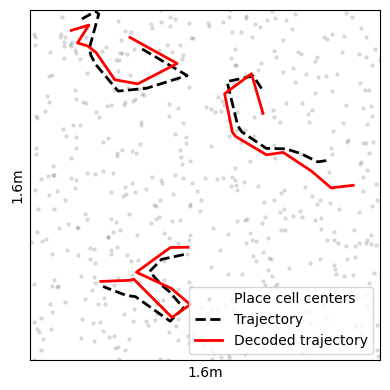

In [33]:
fig, ax = plt.subplots(figsize=(4,4))
ax.scatter(centers[:, 0], centers[:, 1], s=5, color='black', alpha=0.1, label='Place cell centers')
np.random.seed(2)
for k in range(3):
    ind = np.random.randint(0, len(pred))
    ax.plot(pos[ind, :, 0], pos[ind, :, 1], color='k', label='Trajectory', ls='--', lw=2)
    ax.plot(pred[ind, :, 0], pred[ind, :, 1], color='red', label='Decoded trajectory', ls='-', lw=2)
    if k==0:
        ax.legend()
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.8, 0.8)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('1.6m')
ax.set_ylabel('1.6m')
plt.tight_layout()
plt.savefig('../results/emergence/traj.pdf', bbox_inches='tight')
plt.show()


In [34]:
errors = np.sqrt(((pos - pred) ** 2).sum(axis=-1)).mean(axis=-1)
errors_untrained = np.sqrt(((pos_untrain - pred_untrain) ** 2).sum(axis=-1)).mean(axis=-1)

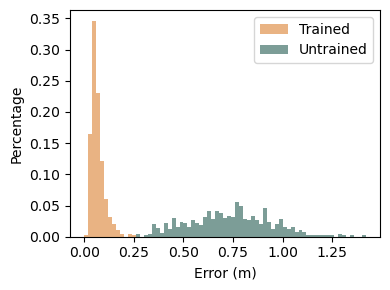

In [35]:
fig, ax = plt.subplots(figsize=(4, 3))
bin_width = 0.02
bins = np.arange(0, max(errors.max(), errors_untrained.max()) + bin_width, bin_width)
ax.hist(errors, bins=bins, color="#e9b383", label='Trained', weights=np.ones_like(errors) / len(errors))
ax.hist(errors_untrained, bins=bins, color="#7c9d97", label='Untrained', weights=np.ones_like(errors_untrained) / len(errors_untrained))
ax.legend()
ax.set_xlabel('Error (m)')
ax.set_ylabel('Percentage')
plt.tight_layout()
plt.savefig('../results/emergence/errors.pdf', bbox_inches='tight')
plt.show()